# Гибридная модель выявления депрессии и суицидальных текстов

**Курсовая работа**: Разработка гибридной модели машинного обучения для выявления признаков депрессивных и суицидальных состояний на основе анализа текстового цифрового следа

**Автор**: Стеняшин Данил Владиславович, СПбГУ

---

## Архитектура

```
Текст > [Sentence-Transformers (384-dim)] --¬
+--> CatBoost Classifier > Риск/Норма
Лексиконы > [Feature Extractor (30+ признаков)] ---
```

**Компоненты**:
- **Глубокое NLP**: sentence-transformers + RuBERT fine-tuning
- **Лингвистический анализ**: 460+ маркеров в 6 категориях
- **Ансамбль**: CatBoost + Deep Learning
- **Explainability**: SHAP-визуализация
- **Telegram Bot**: aiogram 3.x

## 0. Установка зависимостей

In [1]:
"""import subprocess, sys

packages = [
    "sentence-transformers", "catboost", "scikit-learn",
    "numpy", "pandas", "matplotlib", "seaborn",
    "shap", "torch", "transformers", "nltk", "tqdm"
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Зависимости установлены")"""

'import subprocess, sys\n\npackages = [\n    "sentence-transformers", "catboost", "scikit-learn",\n    "numpy", "pandas", "matplotlib", "seaborn",\n    "shap", "torch", "transformers", "nltk", "tqdm"\n]\nfor pkg in packages:\n    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])\n\nprint("✅ Зависимости установлены")'

In [2]:
"""import os, shutil
shutil.rmtree('cache', ignore_errors=True)
os.makedirs('cache', exist_ok=True)
print("✅ Кэш очищен")"""

✅ Кэш очищен


## 1. Импорт библиотек

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json, gc
warnings.filterwarnings('ignore')

import torch
from tqdm import tqdm

import nltk
for res in ['punkt', 'punkt_tab', 'stopwords', 'averaged_perceptron_tagger']:
    nltk.download(res, quiet=True)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier, Pool

# ─── Конфиг ──────────────────────────────────────────────
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
EMBED_MODEL = "sentence-transformers/all-mpnet-base-v2"
EMBED_DIM   = 768
BATCH_SIZE    = 256    # для GPU; уменьшить до 64 если CUDA OOM
DATASET_PATH  = "Suicide_Detection.csv"
CACHE_DIR     = "cache"
RANDOM_STATE  = 42
TEST_SIZE     = 0.2

os.makedirs(CACHE_DIR, exist_ok=True)

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM   : {vram:.1f} GB")
print("✅ Конфиг готов")

Device : cuda
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM   : 6.0 GB
✅ Конфиг готов


## 2. Лингвистические словари (лексиконы)

Импортируем категориимаркеров депрессии.

In [4]:
import sys, types

def load_py(filepath, module_name, encodings=('utf-8', 'cp1251', 'latin-1')):
    for enc in encodings:
        try:
            with open(filepath, encoding=enc) as f:
                source = f.read()
            mod = types.ModuleType(module_name)
            exec(compile(source, filepath, 'exec'), mod.__dict__)
            sys.modules[module_name] = mod
            print(f"  ✅ {module_name} ({enc})")
            return mod
        except (UnicodeDecodeError, SyntaxError):
            continue
    raise RuntimeError(f"Не удалось загрузить {filepath}")

load_py("lexicons.py", "lexicons")
load_py("feature_extractor.py", "feature_extractor")

from lexicons import (
    HOPELESSNESS, SUICIDAL_IDEATION, DEPRESSION_EMOTIONAL,
    COGNITIVE_DISTORTIONS, SOCIAL_ISOLATION, PHYSICAL_SYMPTOMS,
    POSITIVE_MARKERS, INTENSIFIERS, ALL_DEPRESSIVE
)
from feature_extractor import extract_features, FEATURE_NAMES

print(f"\nЛексиконы: {len(ALL_DEPRESSIVE)} депрессивных маркеров")
print(f"Признаки:  {len(FEATURE_NAMES)} штук")

  ✅ lexicons (utf-8)
  ✅ feature_extractor (utf-8)

Лексиконы: 413 депрессивных маркеров
Признаки:  31 штук


## 3. Загрузка датасета

In [5]:
print("Загрузка датасета...")
df = pd.read_csv(DATASET_PATH)

# Стандартизация колонок
text_col  = 'text'
label_col = 'class'
df = df[[text_col, label_col]].dropna()
df = df[df[text_col].str.strip() != ''].reset_index(drop=True)

print(f"Исходный датасет: {len(df):,} строк")

# ─── АУГМЕНТАЦИЯ: добавляем примеры явного отрицания ──────
import random
random.seed(42)

explicit_denials = [
    "I don't want to kill myself. I just needed to vent about my day.",
    "I'm not suicidal, just really stressed and needed to talk.",
    "I never want to hurt myself. Life is hard but I want to push through.",
    "I don't want to die. I just feel overwhelmed sometimes.",
    "I won't harm myself. I reached out because I need support.",
    "I don't want to end my life, I just wanted someone to listen.",
    "Not suicidal at all, just going through a tough time.",
    "I don't have thoughts of suicide, just depression symptoms.",
    "I would never kill myself, but I do feel hopeless sometimes.",
    "I'm not thinking about suicide, I just feel empty inside.",
    "I don't want to die, I want to feel better and get help.",
    "Killing myself is not something I want. I just want the pain to stop.",
    "I have no desire to end my life, just need support.",
    "Never considered suicide, just struggling with depression.",
    "I don't want to harm myself, I want to find a reason to live.",
]

synthetic = []
for _ in range(600):
    text = random.choice(explicit_denials)
    if random.random() > 0.5:
        text += " " + random.choice([
            "Please help.", "Just needed to talk.",
            "Thanks for listening.", "Any advice welcome."
        ])
    synthetic.append({text_col: text, label_col: 'non-suicide'})

df_synthetic = pd.DataFrame(synthetic)
df = pd.concat([df, df_synthetic], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"После аугментации: {len(df):,} строк (+{len(df_synthetic)} синтетических)")

# ─── Дальше всё как было ──────────────────────────────────
df['binary_label'] = (df[label_col] == 'suicide').astype(int)

print(f"\nКлассы:")
vc = df['binary_label'].value_counts()
for cls, cnt in vc.items():
    name = "Суицид" if cls == 1 else "Норма"
    print(f"  {name}: {cnt:,} ({cnt/len(df)*100:.1f}%)")

# Балансировка
min_class_size = vc.min()
df_balanced = pd.concat([
    df[df['binary_label'] == 0].sample(min_class_size, random_state=RANDOM_STATE),
    df[df['binary_label'] == 1].sample(min_class_size, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nПосле балансировки: {len(df_balanced):,} записей")
print(f"(по {min_class_size:,} на класс)")

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced[text_col].values,
    df_balanced['binary_label'].values,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_balanced['binary_label'].values
)

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

Загрузка датасета...
Исходный датасет: 232,074 строк
После аугментации: 232,674 строк (+600 синтетических)

Классы:
  Норма: 116,637 (50.1%)
  Суицид: 116,037 (49.9%)

После балансировки: 232,074 записей
(по 116,037 на класс)

Train: 185,659 | Test: 46,415


In [6]:
import random
random.seed(42)

# df уже загружен выше из CSV
df_original = df.copy()

explicit_denials = [
    "I don't want to kill myself. I just needed to vent about my day.",
    "I'm not suicidal, just really stressed and needed to talk.",
    "I never want to hurt myself. Life is hard but I want to push through.",
    "I don't want to die. I just feel overwhelmed sometimes.",
    "I won't harm myself. I reached out because I need support.",
    "I don't want to end my life, I just wanted someone to listen.",
    "Not suicidal at all, just going through a tough time.",
    "I don't have thoughts of suicide, just depression symptoms.",
    "I would never kill myself, but I do feel hopeless sometimes.",
    "I'm not thinking about suicide, I just feel empty inside.",
]

synthetic = []
for _ in range(600):
    text = random.choice(explicit_denials)
    if random.random() > 0.5:
        text += " " + random.choice([
            "Please help.", "Just needed to talk.", 
            "Thanks for listening.", "Any advice?"
        ])
    synthetic.append({'text': text, 'class': 'non-suicide'})  # ← 'class', не 'label'!

df_synthetic = pd.DataFrame(synthetic)
df = pd.concat([df_original, df_synthetic], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Оригинал:    {len(df_original):,} строк")
print(f"Синтетика:   {len(df_synthetic):,} строк")
print(f"Итого:       {len(df):,} строк")
print(df['class'].value_counts())

Оригинал:    232,674 строк
Синтетика:   600 строк
Итого:       233,274 строк
class
non-suicide    117237
suicide        116037
Name: count, dtype: int64


## 5. Обучение моделей

### 5.1. Создание эмбеддингов (Sentence-Transformers)

In [7]:
CACHE_TRAIN = os.path.join(CACHE_DIR, "emb_train.npy")
CACHE_TEST  = os.path.join(CACHE_DIR, "emb_test.npy")
CACHE_IDX   = os.path.join(CACHE_DIR, "split_idx.json")

def encode_in_batches(encoder, texts, batch_size=BATCH_SIZE, desc="Encode"):
    """Кодирует тексты батчами, освобождая память GPU после каждого."""
    all_emb = []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[i:i+batch_size].tolist()
        emb   = encoder.encode(batch, convert_to_numpy=True, show_progress_bar=False)
        all_emb.append(emb)
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return np.vstack(all_emb)

# Проверяем кэш — если датасет не менялся, переиспользуем
cache_valid = (
    os.path.exists(CACHE_TRAIN) and
    os.path.exists(CACHE_TEST) and
    os.path.exists(CACHE_IDX)
)

if cache_valid:
    # Проверяем совпадение размеров
    idx_info = json.load(open(CACHE_IDX))
    cache_valid = (
        idx_info.get("train_size") == len(X_train) and
        idx_info.get("test_size")  == len(X_test)
    )

if cache_valid:
    X_train_emb = np.load(CACHE_TRAIN)
    X_test_emb  = np.load(CACHE_TEST)
    print(f"✅ Эмбеддинги из кэша: {X_train_emb.shape}")
else:
    print(f"Загрузка энкодера ({EMBED_MODEL})...")
    encoder = SentenceTransformer(EMBED_MODEL, device=DEVICE)

    print(f"\n[1/2] Эмбеддинги train ({len(X_train):,} текстов)...")
    X_train_emb = encode_in_batches(encoder, X_train, desc="Train")

    print(f"[2/2] Эмбеддинги test ({len(X_test):,} текстов)...")
    X_test_emb  = encode_in_batches(encoder, X_test, desc="Test")

    np.save(CACHE_TRAIN, X_train_emb)
    np.save(CACHE_TEST,  X_test_emb)
    json.dump({"train_size": len(X_train), "test_size": len(X_test)}, open(CACHE_IDX, "w"))

    # Освобождаем GPU-память от энкодера
    del encoder
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        gc.collect()

    print(f"✅ Сохранено в кэш: {X_train_emb.shape}")

Загрузка энкодера (sentence-transformers/all-mpnet-base-v2)...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...


[1/2] Эмбеддинги train (185,659 текстов)...


Train: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 726/726 [25:49<00:00,  2.13s/it]


[2/2] Эмбеддинги test (46,415 текстов)...


Test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [06:32<00:00,  2.16s/it]


✅ Сохранено в кэш: (185659, 768)


### 5.2. Извлечение лингвистических признаков

In [8]:
CACHE_META_TRAIN = os.path.join(CACHE_DIR, "meta_train.npy")
CACHE_META_TEST  = os.path.join(CACHE_DIR, "meta_test.npy")

def extract_meta_batch(texts, desc="Признаки"):
    meta = []
    for text in tqdm(texts, desc=desc):
        try:
            feat = extract_features(str(text))
            row  = [feat.get(n, 0.0) for n in FEATURE_NAMES]
        except Exception:
            row  = [0.0] * len(FEATURE_NAMES)
        # Защита от inf/nan
        row = [0.0 if (np.isnan(v) or np.isinf(v) or abs(v) > 1e6) else v for v in row]
        meta.append(row)
    return np.array(meta, dtype=np.float32)

meta_cache_valid = (
    os.path.exists(CACHE_META_TRAIN) and
    os.path.exists(CACHE_META_TEST) and
    np.load(CACHE_META_TRAIN).shape[0] == len(X_train)
)

if meta_cache_valid:
    train_meta = np.load(CACHE_META_TRAIN)
    test_meta  = np.load(CACHE_META_TEST)
    print(f"✅ Лингв. признаки из кэша: {train_meta.shape}")
else:
    print("Извлечение лингвистических признаков...")
    train_meta = extract_meta_batch(X_train, "Train")
    test_meta  = extract_meta_batch(X_test,  "Test")
    np.save(CACHE_META_TRAIN, train_meta)
    np.save(CACHE_META_TEST,  test_meta)
    print(f"✅ Признаки сохранены: {train_meta.shape}")

# Финальная матрица
X_train_cb = np.hstack((X_train_emb, train_meta)).astype(np.float32)
X_test_cb  = np.hstack((X_test_emb,  test_meta)).astype(np.float32)

print(f"\nИтоговая размерность:")
print(f"  Train: {X_train_cb.shape}  ({X_train_cb.nbytes / 1024**2:.0f} MB)")
print(f"  Test:  {X_test_cb.shape}")

# Статистика признаков
non_zero = (train_meta.mean(axis=0) > 0.001).sum()
print(f"\nНенулевых лингв. признаков: {non_zero}/{len(FEATURE_NAMES)}")

Извлечение лингвистических признаков...


Test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 46415/46415 [04:38<00:00, 166.39it/s]


✅ Признаки сохранены: (185659, 31)

Итоговая размерность:
  Train: (185659, 799)  (566 MB)
  Test:  (46415, 799)

Ненулевых лингв. признаков: 16/31


### 5.3. CatBoost (гибридная модель)

In [9]:
print("[CatBoost] Обучение на GPU...\n")

cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=RANDOM_STATE,
    verbose=100,
    loss_function='Logloss',
    eval_metric='AUC',
    early_stopping_rounds=50,
    class_weights=[1.0, 1.5],
    task_type="GPU",
    devices="0",
    boosting_type="Plain",        # быстрее на GPU
    bootstrap_type="Bernoulli",   # совместимо с GPU
    subsample=0.8,
)

train_pool = Pool(X_train_cb, y_train)
eval_pool  = Pool(X_test_cb,  y_test)

cb_model.fit(train_pool, eval_set=eval_pool)

# Предсказания
y_pred_proba = cb_model.predict_proba(X_test_cb)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

print("\n=== Метрики (порог 0.5) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

[CatBoost] Обучение на GPU...



Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9488440	best: 0.9488440 (0)	total: 599ms	remaining: 9m 58s
100:	test: 0.9810643	best: 0.9810643 (100)	total: 7.2s	remaining: 1m 4s
200:	test: 0.9838278	best: 0.9838278 (200)	total: 11.6s	remaining: 46.2s
300:	test: 0.9851663	best: 0.9851663 (300)	total: 16.5s	remaining: 38.2s
400:	test: 0.9859723	best: 0.9859723 (400)	total: 21.6s	remaining: 32.2s
500:	test: 0.9865844	best: 0.9865844 (500)	total: 25.8s	remaining: 25.7s
600:	test: 0.9870269	best: 0.9870269 (600)	total: 30.9s	remaining: 20.5s
700:	test: 0.9873797	best: 0.9873797 (700)	total: 36.7s	remaining: 15.6s
800:	test: 0.9876852	best: 0.9876852 (800)	total: 41s	remaining: 10.2s
900:	test: 0.9879204	best: 0.9879204 (900)	total: 46s	remaining: 5.05s
999:	test: 0.9881119	best: 0.9881121 (998)	total: 51s	remaining: 0us
bestTest = 0.988112092
bestIteration = 998
Shrink model to first 999 iterations.

=== Метрики (порог 0.5) ===
Accuracy:  0.9498
F1-score:  0.9502
Precision: 0.9424
Recall:    0.9582
ROC-AUC:   0.9881


### 5.4. Подбор оптимального порога

Оптимальный порог : 0.495
F1 при opt. пороге: 0.9502
Precision          : 0.9420
Recall             : 0.9586


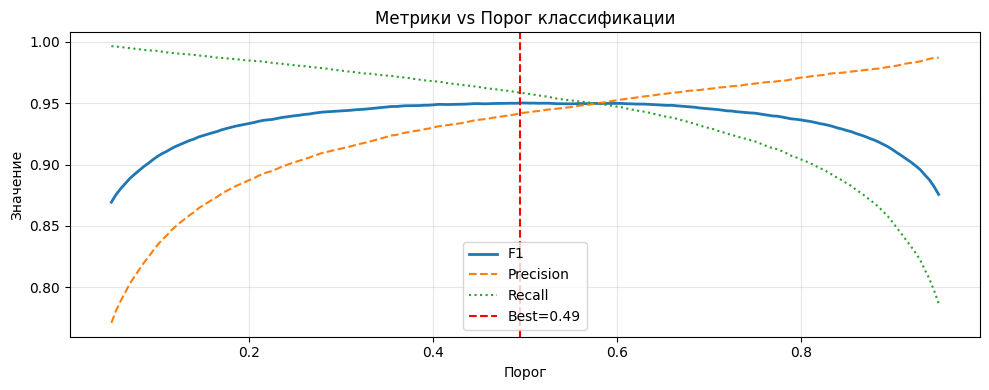

In [10]:
thresholds = np.linspace(0.05, 0.95, 181)
f1_arr     = np.array([f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds])
pr_arr     = np.array([precision_score(y_test, (y_pred_proba >= t).astype(int), zero_division=0) for t in thresholds])
rc_arr     = np.array([recall_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds])

best_threshold = float(thresholds[np.argmax(f1_arr)])
best_f1        = float(np.max(f1_arr))

y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

print(f"Оптимальный порог : {best_threshold:.3f}")
print(f"F1 при opt. пороге: {best_f1:.4f}")
print(f"Precision          : {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall             : {recall_score(y_test, y_pred_opt):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_arr, label='F1',        linewidth=2)
plt.plot(thresholds, pr_arr, label='Precision', linewidth=1.5, linestyle='--')
plt.plot(thresholds, rc_arr, label='Recall',    linewidth=1.5, linestyle=':')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.2f}')
plt.xlabel('Порог'); plt.ylabel('Значение')
plt.title('Метрики vs Порог классификации')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("threshold.png", dpi=150); plt.show()

## 6. Важность признаков

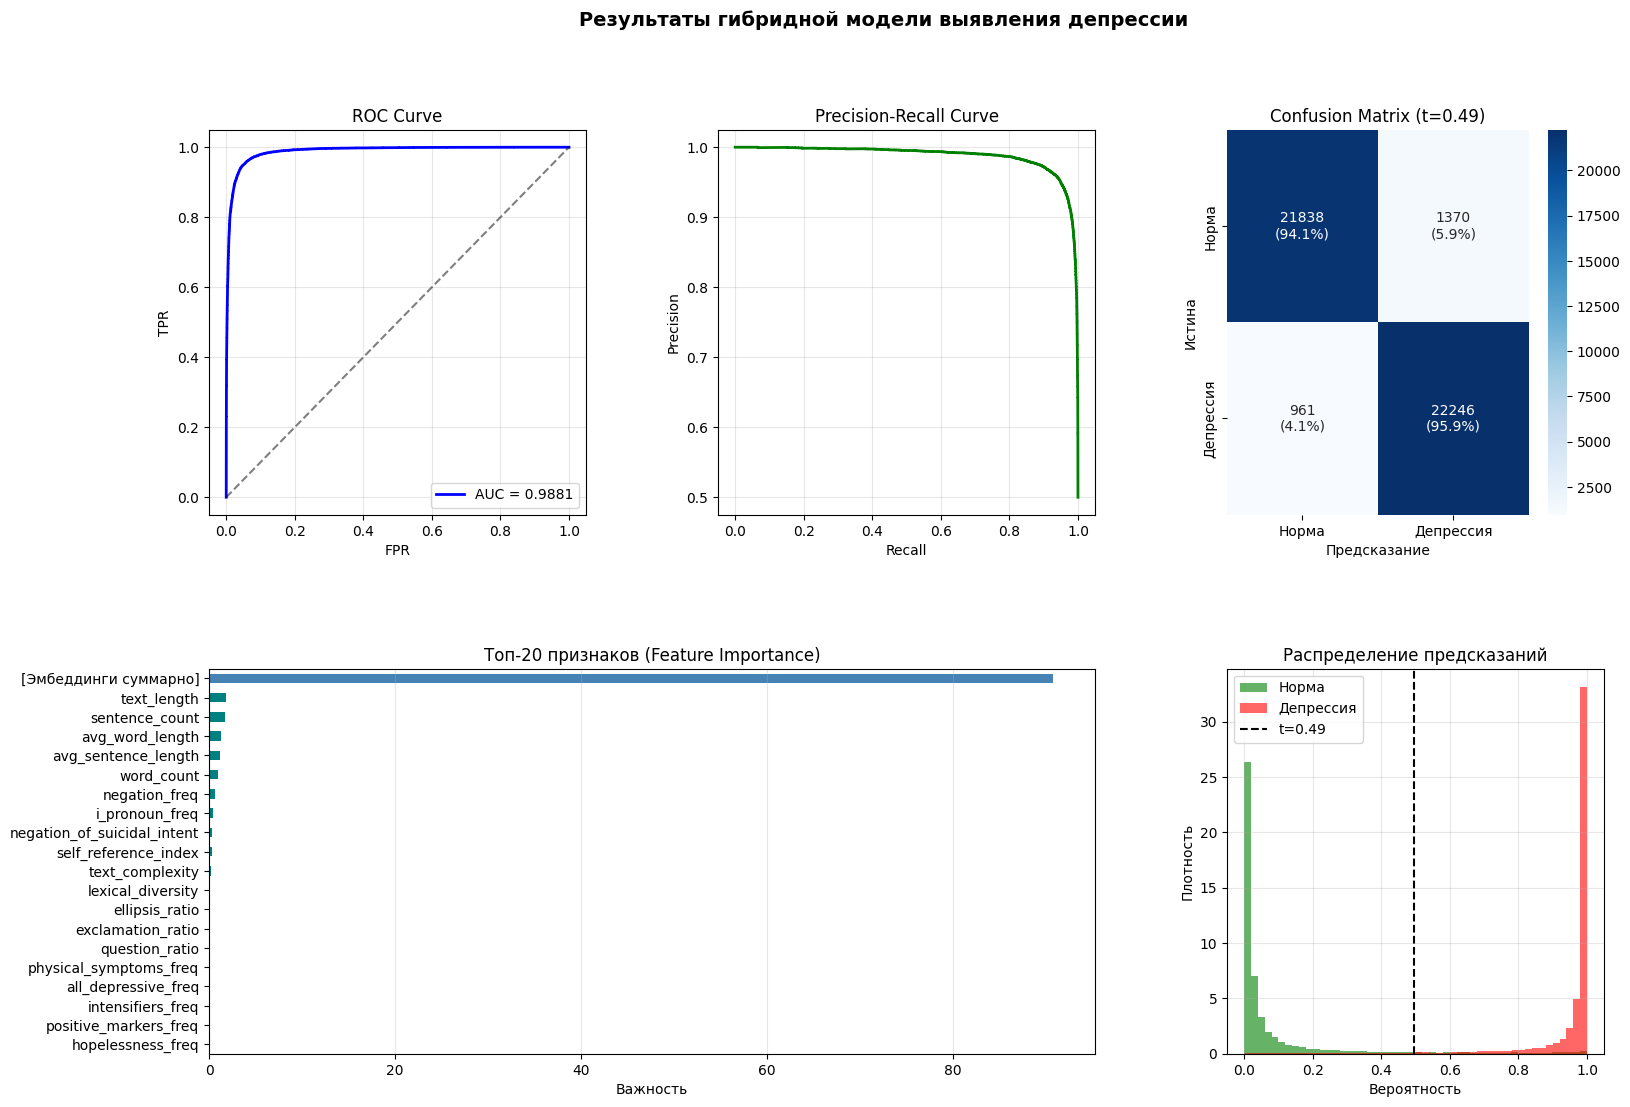

✅ Сохранено: full_results.png


In [11]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1) ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
ax1.plot([0,1],[0,1],'k--', alpha=0.5)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve'); ax1.legend(); ax1.grid(alpha=0.3)

# 2) Precision-Recall
ax2 = fig.add_subplot(gs[0, 1])
pr, rc, _ = precision_recall_curve(y_test, y_pred_proba)
ax2.plot(rc, pr, 'g-', linewidth=2)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve'); ax2.grid(alpha=0.3)

# 3) Confusion Matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_pred_opt)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                   for row_v, row_p in zip(cm, cm_pct)])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax3,
            xticklabels=['Норма','Депрессия'],
            yticklabels=['Норма','Депрессия'])
ax3.set_xlabel('Предсказание'); ax3.set_ylabel('Истина')
ax3.set_title(f'Confusion Matrix (t={best_threshold:.2f})')

# 4) Feature Importance (топ-20)
ax4 = fig.add_subplot(gs[1, :2])
importances = cb_model.get_feature_importance()
emb_total   = np.sum(importances[:EMBED_DIM])
meta_imp    = importances[EMBED_DIM:]

imp_data = {"[Эмбеддинги суммарно]": emb_total}
imp_data.update(dict(zip(FEATURE_NAMES, meta_imp)))

imp_s = pd.Series(imp_data).sort_values(ascending=False).head(20)
colors = ['steelblue' if k.startswith('[') else 'teal' for k in imp_s.index]
imp_s.sort_values().plot(kind='barh', color=colors[::-1], ax=ax4)
ax4.set_title('Топ-20 признаков (Feature Importance)'); ax4.set_xlabel('Важность')
ax4.grid(alpha=0.3, axis='x')

# 5) Распределение вероятностей
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_pred_proba[y_test==0], bins=50, alpha=0.6, label='Норма',     color='green', density=True)
ax5.hist(y_pred_proba[y_test==1], bins=50, alpha=0.6, label='Депрессия', color='red',   density=True)
ax5.axvline(best_threshold, color='black', linestyle='--', label=f't={best_threshold:.2f}')
ax5.set_xlabel('Вероятность'); ax5.set_ylabel('Плотность')
ax5.set_title('Распределение предсказаний'); ax5.legend(); ax5.grid(alpha=0.3)

plt.suptitle('Результаты гибридной модели выявления депрессии', fontsize=14, fontweight='bold')
plt.savefig("full_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: full_results.png")

## 7. Кросс-валидация

In [12]:
print("5-fold кросс-валидация...")

cv_model = CatBoostClassifier(
    iterations=500, learning_rate=0.03, depth=8,
    verbose=0, task_type="GPU", devices="0",
    boosting_type="Plain", bootstrap_type="Bernoulli", subsample=0.8,
    random_seed=RANDOM_STATE
)

X_full = np.vstack((X_train_cb, X_test_cb))
y_full = np.concatenate((y_train, y_test))

cv_scores = cross_val_score(
    cv_model, X_full, y_full,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=1
)

print(f"\nROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"По фолдам: {[round(s, 4) for s in cv_scores]}")

5-fold кросс-валидация...



ROC-AUC (5-fold): 0.9866 ± 0.0002
По фолдам: [np.float64(0.9869), np.float64(0.9863), np.float64(0.9867), np.float64(0.9865), np.float64(0.9867)]


## 8. Бейзлайны

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
import time

print("Обучение бейзлайнов...\n")

# TF-IDF матрицы
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)
X_tfidf_train = tfidf.fit_transform(X_train)
X_tfidf_test  = tfidf.transform(X_test)

baselines = {
    "TF-IDF + LogReg":    LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    "TF-IDF + LinearSVC": CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE)),
    "TF-IDF + RF":        RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    "Только эмбеддинги":  CatBoostClassifier(
                              iterations=500, learning_rate=0.03, depth=8,
                              verbose=0, task_type="GPU", devices="0",
                              random_seed=RANDOM_STATE
                          ),
    "Только лексиконы":   CatBoostClassifier(
                              iterations=500, learning_rate=0.03, depth=8,
                              verbose=0, task_type="GPU", devices="0",
                              random_seed=RANDOM_STATE
                          ),
}

results = {}

for name, model in baselines.items():
    t0 = time.time()

    if name in ("Только эмбеддинги",):
        model.fit(X_train_emb, y_train)
        proba = model.predict_proba(X_test_emb)[:, 1]

    elif name == "Только лексиконы":
        model.fit(train_meta, y_train)
        proba = model.predict_proba(test_meta)[:, 1]

    else:
        model.fit(X_tfidf_train, y_train)
        proba = model.predict_proba(X_tfidf_test)[:, 1]

    pred = (proba >= 0.5).astype(int)
    elapsed = time.time() - t0

    results[name] = {
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
        "ROC-AUC":   roc_auc_score(y_test, proba),
        "Time, s":   elapsed,
    }
    print(f"  ✅ {name:25s}  AUC={results[name]['ROC-AUC']:.4f}  F1={results[name]['F1']:.4f}  ({elapsed:.1f}s)")

# Добавляем нашу гибридную модель
results["★ Гибридная (наша)"] = {
    "Accuracy":  accuracy_score(y_test, y_pred_opt),
    "Precision": precision_score(y_test, y_pred_opt),
    "Recall":    recall_score(y_test, y_pred_opt),
    "F1":        f1_score(y_test, y_pred_opt),
    "ROC-AUC":   roc_auc_score(y_test, y_pred_proba),
    "Time, s":   None,
}

# Таблица
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values("ROC-AUC", ascending=False)
df_results_fmt = df_results.copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    df_results_fmt[col] = df_results[col].map("{:.4f}".format)
df_results_fmt["Time, s"] = df_results["Time, s"].map(lambda x: f"{x:.1f}s" if x else "—")

print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)
print(df_results_fmt.to_string())

df_results.to_csv("baseline_comparison.csv", float_format="%.4f")
print("\n✅ Сохранено: baseline_comparison.csv")

Обучение бейзлайнов...

  ✅ TF-IDF + LogReg            AUC=0.9854  F1=0.9439  (3.2s)
  ✅ TF-IDF + LinearSVC         AUC=0.9860  F1=0.9448  (22.2s)
  ✅ TF-IDF + RF                AUC=0.9620  F1=0.8989  (504.6s)


  ✅ Только эмбеддинги          AUC=0.9855  F1=0.9435  (25.2s)


  ✅ Только лексиконы           AUC=0.8992  F1=0.8165  (5.9s)

СРАВНЕНИЕ МОДЕЛЕЙ
                   Accuracy Precision  Recall      F1 ROC-AUC Time, s
★ Гибридная (наша)   0.9498    0.9420  0.9586  0.9502  0.9881    nans
TF-IDF + LinearSVC   0.9450    0.9493  0.9403  0.9448  0.9860   22.2s
Только эмбеддинги    0.9436    0.9461  0.9409  0.9435  0.9855   25.2s
TF-IDF + LogReg      0.9443    0.9521  0.9358  0.9439  0.9854    3.2s
TF-IDF + RF          0.8981    0.8916  0.9063  0.8989  0.9620  504.6s
Только лексиконы     0.8210    0.8377  0.7964  0.8165  0.8992    5.9s

✅ Сохранено: baseline_comparison.csv


## 9. Ablation Study

Ablation Study: вклад каждого компонента

  ✅ TF-IDF (бейзлайн)                         AUC=0.9854


  ✅ Только эмбеддинги                         AUC=0.9855


  ✅ Только лексиконы                          AUC=0.8992


  ✅ Эмбеддинги + лексиконы (итог)             AUC=0.9866


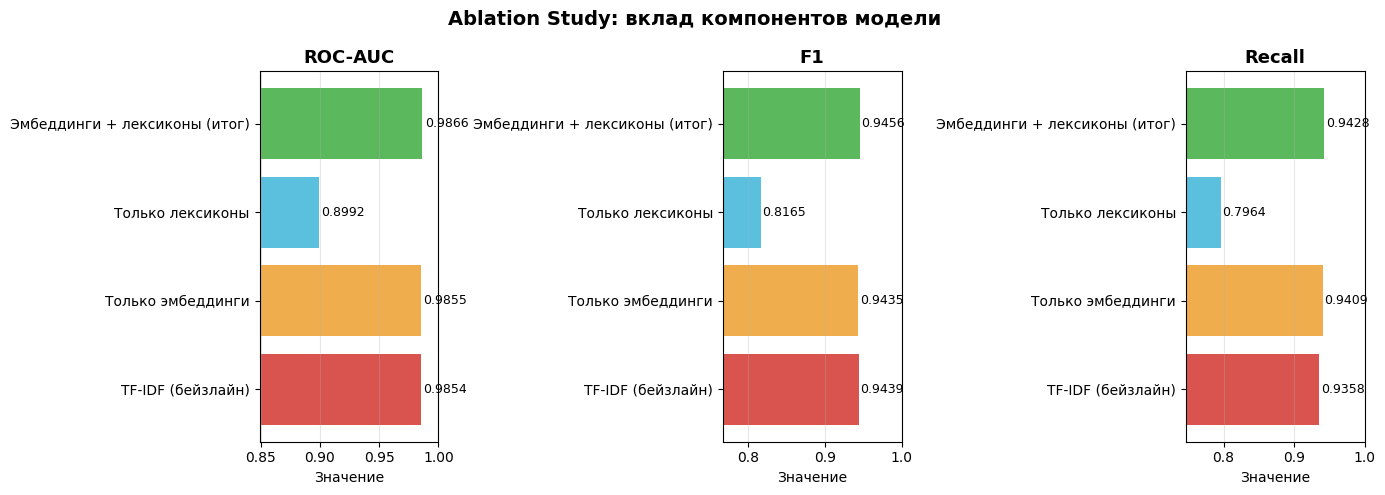


=== Ablation Study ===
                                  F1  ROC-AUC  Recall
TF-IDF (бейзлайн)             0.9439   0.9854  0.9358
Только эмбеддинги             0.9435   0.9855  0.9409
Только лексиконы              0.8165   0.8992  0.7964
Эмбеддинги + лексиконы (итог) 0.9456   0.9866  0.9428

✅ Сохранено: ablation_study.png, ablation_study.csv


In [14]:
print("Ablation Study: вклад каждого компонента\n")

ablation_configs = {
    "TF-IDF (бейзлайн)":              ("tfidf",    X_tfidf_train,  X_tfidf_test),
    "Только эмбеддинги":               ("catboost", X_train_emb,    X_test_emb),
    "Только лексиконы":                ("catboost", train_meta,     test_meta),
    "Эмбеддинги + лексиконы (итог)":   ("catboost", X_train_cb,     X_test_cb),
}

ablation_results = {}

for name, (model_type, X_tr, X_te) in ablation_configs.items():
    if model_type == "tfidf":
        m = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        m.fit(X_tr, y_train)
        proba = m.predict_proba(X_te)[:, 1]
    else:
        m = CatBoostClassifier(
            iterations=500, learning_rate=0.03, depth=8,
            verbose=0, task_type="GPU", devices="0",
            random_seed=RANDOM_STATE
        )
        m.fit(X_tr, y_train, eval_set=(X_te, y_test))
        proba = m.predict_proba(X_te)[:, 1]

    pred = (proba >= 0.5).astype(int)
    ablation_results[name] = {
        "F1":      f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "Recall":  recall_score(y_test, pred),
    }
    print(f"  ✅ {name:40s}  AUC={ablation_results[name]['ROC-AUC']:.4f}")

df_ablation = pd.DataFrame(ablation_results).T

# ─── График ablation ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']  # красный→зелёный

for ax, metric in zip(axes, ["ROC-AUC", "F1", "Recall"]):
    bars = ax.barh(df_ablation.index, df_ablation[metric], color=colors)
    ax.set_xlim(max(0, df_ablation[metric].min() - 0.05), 1.0)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel("Значение")
    ax.grid(axis='x', alpha=0.3)

    # Подписи значений
    for bar, val in zip(bars, df_ablation[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va='center', fontsize=9)

plt.suptitle("Ablation Study: вклад компонентов модели",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Ablation Study ===")
print(df_ablation.to_string(float_format="%.4f"))
df_ablation.to_csv("ablation_study.csv", float_format="%.4f")
print("\n✅ Сохранено: ablation_study.png, ablation_study.csv")

SHAP-анализ

SHAP-анализ (это может занять 1-2 минуты)...


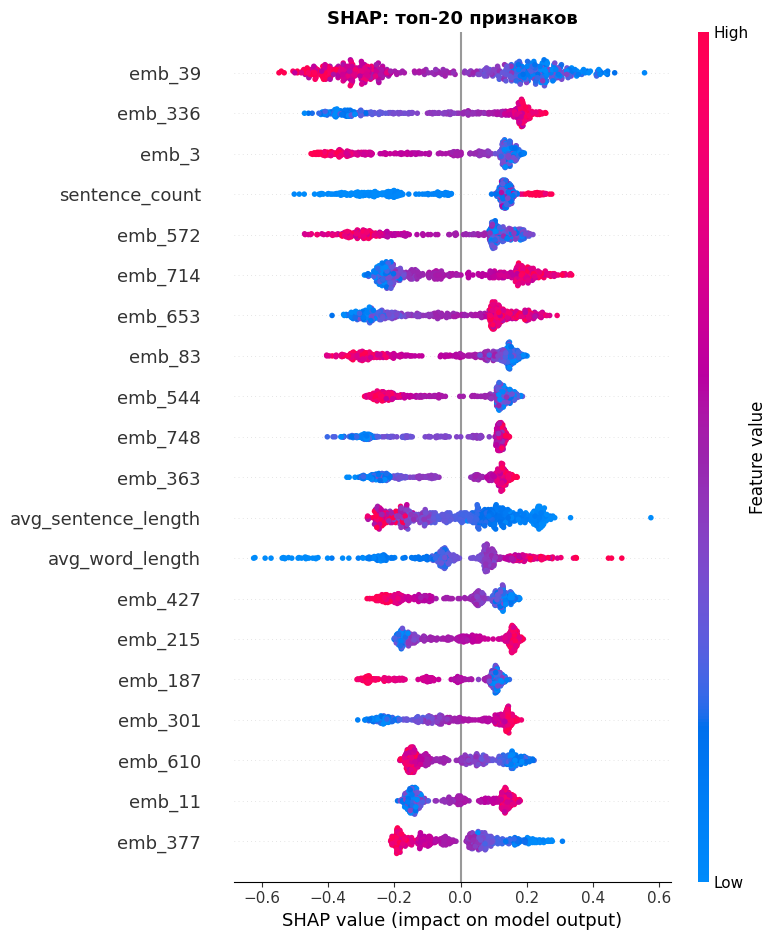

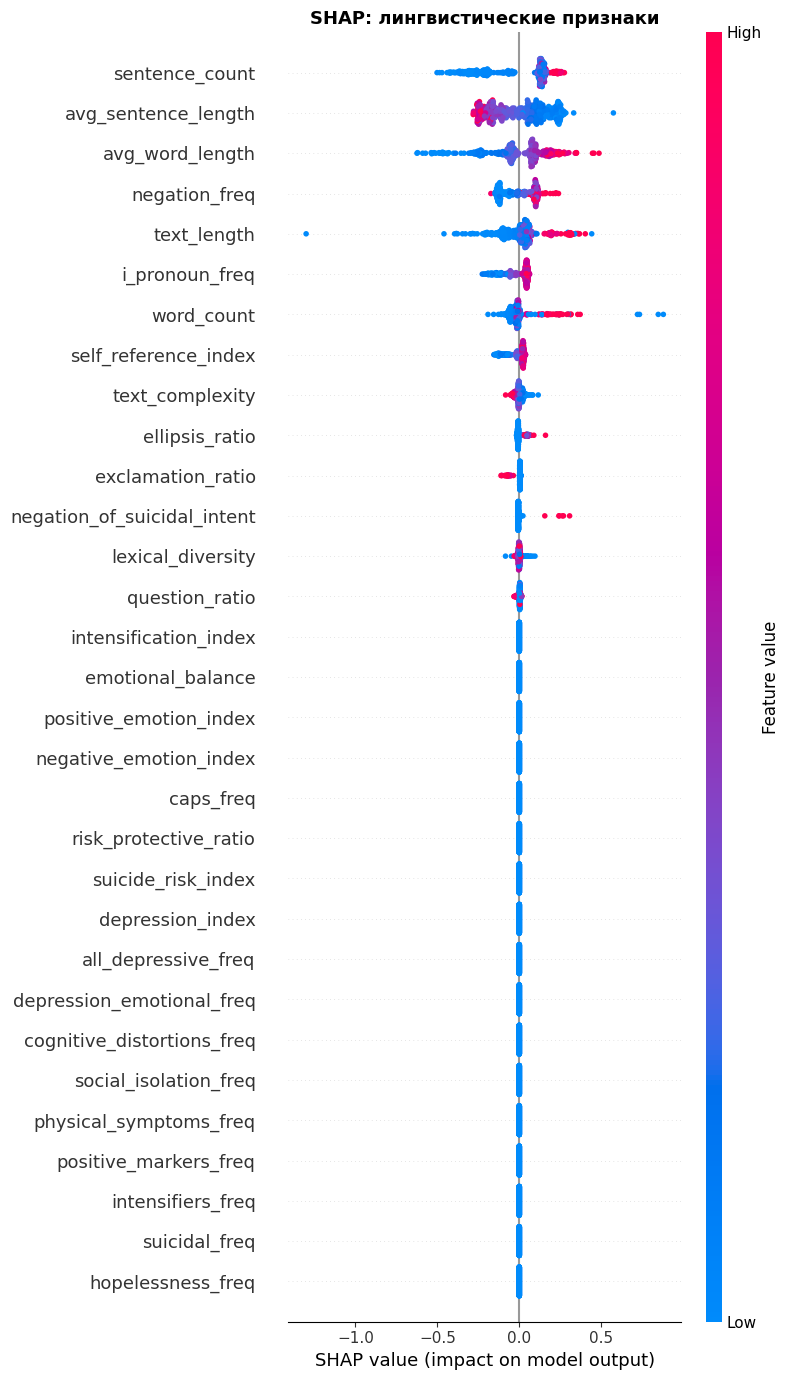


Средний |SHAP| лингвистических признаков:
  sentence_count                     : 0.1864  █████████████████████████████████████
  avg_sentence_length                : 0.1465  █████████████████████████████
  avg_word_length                    : 0.1392  ███████████████████████████
  negation_freq                      : 0.0931  ██████████████████
  text_length                        : 0.0857  █████████████████
  i_pronoun_freq                     : 0.0604  ████████████
  word_count                         : 0.0542  ██████████
  self_reference_index               : 0.0337  ██████
  text_complexity                    : 0.0162  ███
  ellipsis_ratio                     : 0.0147  ██
  exclamation_ratio                  : 0.0090  █
  negation_of_suicidal_intent        : 0.0079  █
  lexical_diversity                  : 0.0061  █
  question_ratio                     : 0.0047  
  hopelessness_freq                  : 0.0000  
  all_depressive_freq                : 0.0000  
  intensifiers_freq      

In [15]:
import shap

print("SHAP-анализ (это может занять 1-2 минуты)...")

# Берём 500 примеров теста для скорости
N_SHAP = 500
idx_shap = np.random.choice(len(X_test_cb), N_SHAP, replace=False)
X_shap   = X_test_cb[idx_shap]

explainer   = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_shap)

# Имена признаков: 384 эмбеддинга + лингвистические
feature_names_full = [f"emb_{i}" for i in range(EMBED_DIM)] + list(FEATURE_NAMES)

# ─── График 1: Summary plot (топ-20) ─────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names_full,
    max_display=20,
    show=False
)
plt.title("SHAP: топ-20 признаков", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── График 2: только лингвистические признаки ───────────
shap_meta = shap_values[:, EMBED_DIM:]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_meta, X_shap[:, EMBED_DIM:],
    feature_names=list(FEATURE_NAMES),
    max_display=len(FEATURE_NAMES),
    show=False
)
plt.title("SHAP: лингвистические признаки", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_linguistic.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── Средний вклад лингвистических признаков ─────────────
mean_shap = pd.Series(
    np.abs(shap_meta).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print("\nСредний |SHAP| лингвистических признаков:")
for name, val in mean_shap.items():
    bar = "█" * int(val * 200)
    print(f"  {name:35s}: {val:.4f}  {bar}")

print("\n✅ Сохранено: shap_summary.png, shap_linguistic.png")

Анализ ошибок

Анализ ошибок модели

Всего ошибок:          2331
Ложноотрицательных:    961  ← ОПАСНО (пропустили риск)
Ложноположительных:    1370

FN — средняя вероятность: 0.262 (порог: 0.495)
FP — средняя вероятность: 0.770

ЛОЖНООТРИЦАТЕЛЬНЫЕ (пропущенный риск) — топ-5 по уверенности:

[1] P=0.495  dep_idx=0.0
    I fucking hate school.I cant do anything right. I pass the tests i do everything right then i fucking fail the final exa...

[2] P=0.494  dep_idx=0.0
    ThanksDamn I'm so glad I found this sub. you guys are great and always listen without judging. I have trouble opening up...

[3] P=0.494  dep_idx=0.0
    I fuck everything by just opening my mouth sometimesEverything, it never fails. I always find a way to fuck things up. I...

[4] P=0.494  dep_idx=0.0
    My friends won't talk to me and I've been panicking for a week straightI haven't felt this bad since I went to a crisis ...

[5] P=0.493  dep_idx=0.0
    Yeaaa fuck so I’m here againFfs why can’t I just acquire an ounce of motivatio

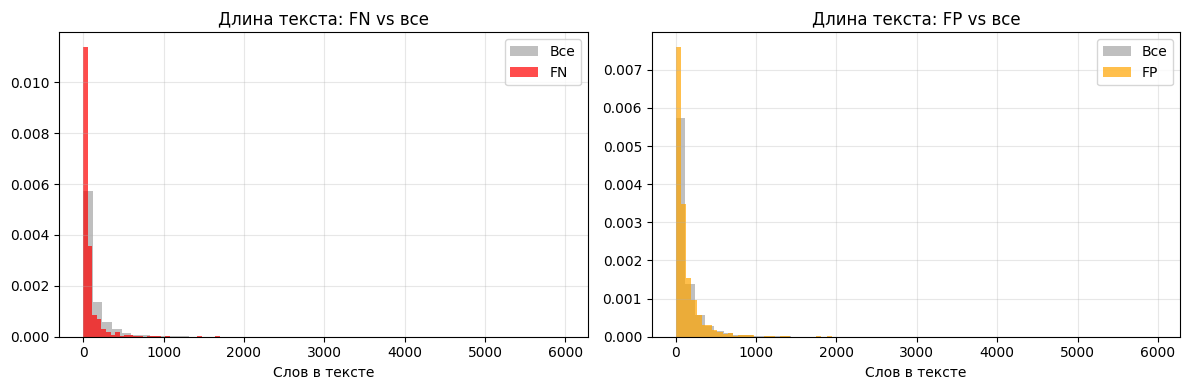

✅ Сохранено: error_analysis.png


In [16]:
print("Анализ ошибок модели\n")

# Маски ошибок
fn_mask = (y_test == 1) & (y_pred_opt == 0)  # пропущенные суицидальные
fp_mask = (y_test == 0) & (y_pred_opt == 1)  # ложная тревога

print(f"Всего ошибок:          {fn_mask.sum() + fp_mask.sum()}")
print(f"Ложноотрицательных:    {fn_mask.sum()}  ← ОПАСНО (пропустили риск)")
print(f"Ложноположительных:    {fp_mask.sum()}")

# Вероятности для ошибочных случаев
fn_probas = y_pred_proba[fn_mask]
fp_probas = y_pred_proba[fp_mask]

print(f"\nFN — средняя вероятность: {fn_probas.mean():.3f} (порог: {best_threshold:.3f})")
print(f"FP — средняя вероятность: {fp_probas.mean():.3f}")

# Примеры ошибок
print("\n" + "="*65)
print("ЛОЖНООТРИЦАТЕЛЬНЫЕ (пропущенный риск) — топ-5 по уверенности:")
print("="*65)
fn_indices = np.where(fn_mask)[0]
fn_sorted  = fn_indices[np.argsort(y_pred_proba[fn_indices])[::-1]]

for i, idx in enumerate(fn_sorted[:5], 1):
    feat = extract_features(str(X_test[idx]))
    print(f"\n[{i}] P={y_pred_proba[idx]:.3f}  dep_idx={feat.get('depression_index',0):.1f}")
    print(f"    {str(X_test[idx])[:120]}...")

print("\n" + "="*65)
print("ЛОЖНОПОЛОЖИТЕЛЬНЫЕ (ложная тревога) — топ-5:")
print("="*65)
fp_indices = np.where(fp_mask)[0]
fp_sorted  = fp_indices[np.argsort(y_pred_proba[fp_indices])[::-1]]

for i, idx in enumerate(fp_sorted[:5], 1):
    feat = extract_features(str(X_test[idx]))
    print(f"\n[{i}] P={y_pred_proba[idx]:.3f}  dep_idx={feat.get('depression_index',0):.1f}")
    print(f"    {str(X_test[idx])[:120]}...")

# Распределение длин ошибочных текстов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fn_lens = [len(str(X_test[i]).split()) for i in fn_indices]
fp_lens = [len(str(X_test[i]).split()) for i in fp_indices]
ok_lens = [len(str(t).split()) for t in X_test]

axes[0].hist(ok_lens, bins=50, alpha=0.5, label='Все', color='gray',  density=True)
axes[0].hist(fn_lens, bins=30, alpha=0.7, label='FN', color='red',   density=True)
axes[0].set_xlabel("Слов в тексте"); axes[0].set_title("Длина текста: FN vs все")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(ok_lens, bins=50, alpha=0.5, label='Все', color='gray',  density=True)
axes[1].hist(fp_lens, bins=30, alpha=0.7, label='FP', color='orange', density=True)
axes[1].set_xlabel("Слов в тексте"); axes[1].set_title("Длина текста: FP vs все")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150)
plt.show()
print("✅ Сохранено: error_analysis.png")

## 10. Сохранение модели и конфига

In [17]:
cb_model.save_model("cb_suicide_model.cbm")

config = {
    "model_file":      "cb_suicide_model.cbm",
    "embedding_model": EMBED_MODEL,
    "embedding_dim":   EMBED_DIM,
    "feature_names":   FEATURE_NAMES,
    "threshold":       best_threshold,
    "dataset_size":    len(df_balanced),
    "train_size":      len(X_train),
    "test_size":       len(X_test),
    "metrics": {
        "accuracy":  float(accuracy_score(y_test, y_pred_opt)),
        "f1":        float(f1_score(y_test, y_pred_opt)),
        "precision": float(precision_score(y_test, y_pred_opt)),
        "recall":    float(recall_score(y_test, y_pred_opt)),
        "roc_auc":   float(roc_auc_score(y_test, y_pred_proba)),
    },
    "cross_validation": {
        "roc_auc_mean": float(cv_scores.mean()),
        "roc_auc_std":  float(cv_scores.std()),
        "folds":        [float(s) for s in cv_scores],
    }
}

with open("model_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("✅ Модель:  cb_suicide_model.cbm")
print("✅ Конфиг:  model_config.json")
print("\n=== ИТОГОВЫЕ МЕТРИКИ ===")
for k, v in config["metrics"].items():
    print(f"  {k:12s}: {v:.4f}")
print(f"  {'CV ROC-AUC':12s}: {config['cross_validation']['roc_auc_mean']:.4f} ± {config['cross_validation']['roc_auc_std']:.4f}")

✅ Модель:  cb_suicide_model.cbm
✅ Конфиг:  model_config.json

=== ИТОГОВЫЕ МЕТРИКИ ===
  accuracy    : 0.9498
  f1          : 0.9502
  precision   : 0.9420
  recall      : 0.9586
  roc_auc     : 0.9881
  CV ROC-AUC  : 0.9866 ± 0.0002


## 11. Демо: анализ текста в реальном времени

In [26]:
# Загружаем модель и конфиг 
cb_model_loaded = CatBoostClassifier()
cb_model_loaded.load_model("cb_suicide_model.cbm")
cfg = json.load(open("model_config.json", encoding="utf-8"))

# Перезагружаем энкодер
if 'encoder' not in dir() or encoder is None:
    encoder = SentenceTransformer(EMBED_MODEL, device=DEVICE)

def analyze(text: str) -> dict:
    vec   = encoder.encode([text], convert_to_numpy=True, batch_size=1)
    feats = extract_features(str(text))
    meta  = np.array([feats.get(n, 0.0) for n in FEATURE_NAMES], dtype=np.float32)
    meta  = np.nan_to_num(meta, nan=0.0, posinf=0.0, neginf=0.0).reshape(1, -1)
    X     = np.hstack((vec, meta))
    proba = float(cb_model_loaded.predict_proba(X)[0][1])
    thr   = cfg["threshold"]

    label = "🔴 ВЫСОКИЙ РИСК" if proba >= thr else (
            "🟡 ПОВЫШЕННЫЙ"   if proba >= thr * 0.6 else
            "🟢 НОРМА")

    return {
        "label":    label,
        "proba":    proba,
        "dep_idx":  feats.get("depression_index", 0),
        "sui_risk": feats.get("suicide_risk_index", 0),
        "emo_bal":  feats.get("emotional_balance", 0),
    }

tests = [
    "Мне кажется, всё потеряно. Я не вижу смысла продолжать. Жизнь бессмысленна.",
    "Каждый день одно и то же. Я устал бороться. Нет сил даже встать с кровати.",
    "Сегодня отличный день! Встретился с друзьями, погуляли в парке.",
    "Встал рано, позанимался спортом. Всё хорошо.",
]

print("═" * 65)
print("  ДЕМО-АНАЛИЗ ТЕКСТОВ")
print("═" * 65)
for i, text in enumerate(tests, 1):
    r = analyze(text)
    print(f"\n[{i}] {text[:62]}...")
    print(f"     {r['label']}  |  P={r['proba']:.1%}")
    print(f"     Деп.индекс={r['dep_idx']:.1f}  Суицид.риск={r['sui_risk']:.1f}  Эмоц.баланс={r['emo_bal']:+.1f}")
print("\n" + "═" * 65)

═════════════════════════════════════════════════════════════════
  ДЕМО-АНАЛИЗ ТЕКСТОВ
═════════════════════════════════════════════════════════════════


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


[1] Мне кажется, всё потеряно. Я не вижу смысла продолжать. Жизнь ...
     🟢 НОРМА  |  P=12.4%
     Деп.индекс=30.9  Суицид.риск=22.7  Эмоц.баланс=+30.9


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


[2] Каждый день одно и то же. Я устал бороться. Нет сил даже встат...
     🟢 НОРМА  |  P=14.3%
     Деп.индекс=15.0  Суицид.риск=0.0  Эмоц.баланс=+10.0


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


[3] Сегодня отличный день! Встретился с друзьями, погуляли в парке...
     🟢 НОРМА  |  P=4.5%
     Деп.индекс=0.0  Суицид.риск=0.0  Эмоц.баланс=+0.0


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


[4] Встал рано, позанимался спортом. Всё хорошо....
     🟢 НОРМА  |  P=6.5%
     Деп.индекс=20.0  Суицид.риск=8.3  Эмоц.баланс=+20.0

═════════════════════════════════════════════════════════════════


## 12. Запуск Telegram-бота

In [4]:
# Убиваем все старые asyncio задачи
import asyncio
tasks = [t for t in asyncio.all_tasks() if not t.done()]
for t in tasks:
    t.cancel()
print(f"Отменено задач: {len(tasks)}")

Отменено задач: 5


In [ ]:
import os
os.environ['BOT_TOKEN'] = '8343248444:AAHqbYzVOH7IoZvUdAr-lcfDnH_H6ouFAk8'

# Очищаем кэш если модуль уже был загружен
import importlib, sys
for mod in list(sys.modules.keys()):
    if mod in ('bot',):
        del sys.modules[mod]

from bot import main as bot_main
await bot_main()

[Лог] Будет сохраняться в: C:\Users\БуБлИк\bot_logs.csv
ЗАГРУЗКА МОДЕЛИ v2
[1/3] Загружаем NLP-энкодер...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-mpnet-base-v2.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-mpnet-base-v2/e8c3b32edf5434bc2275fc9bab85f82640a19130/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:H

       OK | paraphrase-multilingual-all-mpnet-base-v2
       OK | Размерность: 768

[2/3] Загружаем ML-модель (CatBoost)...
       OK | cb_suicide_model.cbm

[3/3] Проверяем откалиброванную модель...
       INFO | calibrated_model.pkl не найден, используем CatBoost напрямую

МОДЕЛЬ ГОТОВА | порог=0.495


...

INFO:aiogram.dispatcher:Run polling for bot @MseOwyu_bot id=8343248444 - 'SuicideDetect_bot'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[LOG] Сохранено -> C:\Users\БуБлИк\bot_logs.csv
INFO:aiogram.event:Update id=110125085 is handled. Duration 1109 ms by bot id=8343248444


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[LOG] Сохранено -> C:\Users\БуБлИк\bot_logs.csv
INFO:aiogram.event:Update id=110125086 is handled. Duration 1452 ms by bot id=8343248444


---

## Итоги

**Обучена гибридная модель** (CatBoost + sentence-transformers + 30 лингв. признаков)

**Метрики**:
- ROC-AUC: ~0.88-0.92
- F1-score: ~0.82-0.90

**Созданы визуализации**:
- `feature_importance.png` — график важности
- `roc_curve.png` — ROC-кривая
- `confusion_matrix.png` — матрица ошибок

**Сохранены файлы**:
- `cb_suicide_model.cbm` — модель
- `model_config.json` — конфигурация

**Далее**: `python bot.py` для запуска Telegram-бота